# 3.21 Wavelength Calibration -- Spectral Library for Wavelength Solution

OVERVIEW: Observe 10-50 bright stars at a range of temperatures in order to build a spectral library that can be used to calibrate the wavelength solution of the NIRDA.

MORE DETAILS: The wavelength solution is what tells us for a given target where will each wavelength element of the spectrum fall on the detector. It also ideally tells us the sensitivity of the instrument, which we divide out to get the spectrum back. This is the sort of thing we need a solution for early in commissioning. This could be a good “occultation” activity because we only need a small amount of science time on these targets, but analysis will take some time to get working. Data should be taken after the pointing solution is improved, but otherwise early in commissioning so we can build the wavelength solution.  


DATA PRODUCTS: 

- [Product Identifer: Product Description, as specified in the Pandora Reference Data Plan] 
    

EXIT CRITERIA: Observation obtained, data products generated and results summarized in \[filename\].md


DATA: 5-10 exposures per target at the shortest cadence we can take. This means data taken on the NIRDA with the regular subarray, 25 reads, with every frame stored (no dropped frames).


TARGET CRITERIA: A set of 10-50 bright stars at a range of temperatures. Bright stars here should be Jmag between 7 and 8, which gives us a bright but not saturated target in one 8s exposure.


KEY STAKEHOLDERS: Christina Hedges, ???

### Load In

In [1]:
import pandorasat as ps
import pandorasim as pp
ps.phoenix.get_phoenix_model(teff=7000, jmag=10) ### this may be slow the first time you run it
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR, NIR_ra_shape, NIR_dec_shape, VIS_ra_shape, VIS_dec_shape

### Define a PandoraSat object for calling constants
p = ps.PandoraSat()

## Data Volume

5 observations for 5 different standard stars. Simultaneous VIS and NIR. The observing set up is the same for all targets.

**Setting NIRDA Values**

When using the standard SCIENCE subarray on the NIRDA (task dependent), the following values should be used:
- NIR_xpix = 80 in top variable definition cell 
- NIR_ypix = 400 in top variable definition cell
- NIR_ROI_SizeX = 80 or equivalent variable in XML generation cell
- NIR_ROI_SizeY = 400 or equivalent variable in XML generation cell
- NIR_ROI_StartX = 1968 in XML generation cell
- NIR_ROI_StartY = 824 in XML generation cell

If an observation is using the larger subarray (task-dependent):
- NIR_xpix = 512 in top variable definition cell
- NIR_ypix = 2048 in top variable definition cell
- NIR_ROI_SizeX = 512 or equivalent variable in XML generation cell
- NIR_ROI_SizeY = 2048 or equivalent variable in XML generation cell
- NIR_ROI_StartX = 1536 in XML generation cell
- NIR_ROI_StartY = 1 in XML generation cell

In [ ]:
##### NIR Observations #####

# update these parameters
NIR_xpix                   = 80
NIR_ypix                   = 400
NIR_ROI_StartX             = 1968
NIR_ROI_StartY             = 824
NIR_ROI_SizeX              = 80
NIR_ROI_SizeY              = 400
frames_per_int_NIR         = 25   
stored_frames_per_int_NIR  = 25   
num_int_NIR                = 10   
# observing_time = 6.67*3600 # units of sec

# calculations
frame_time_NIR             = (NIR_xpix+12) * (NIR_ypix+2) * 0.00001 #sec
int_and_reset_time_NIR     = frame_time_NIR * (frames_per_int_NIR+1)
bits_per_int_NIR           = NIR_xpix * NIR_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR
bits_per_sec_NIR           = bits_per_int_NIR / int_and_reset_time_NIR
test_time_NIR              = num_int_NIR * int_and_reset_time_NIR
bits_per_sec_comp_NIR      = bits_per_sec_NIR / compression_fractor_NIR
bits_test_total_NIR        = bits_per_sec_comp_NIR * test_time_NIR
Gbits_test_packet_NIR      = bits_test_total_NIR / 1E9 * 1.1 * 1.25
downlinks_NIR              = Gbits_test_packet_NIR * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations:', Gbits_test_packet_NIR, 'Gbits')
NIR_SC_Integrations = observing_time / (frames_per_int_NIR * frame_time_NIR) #dimensionless
round(NIR_SC_Integrations)

NIR Observations: 0.08800000000000001 Gbits


2597

In [7]:
##### VIS Observations #####

# update these parameters
frames_per_int_VIS      = 25
regions_VIS             = 1
VIS_xpix                = 50
VIS_ypix                = 50
num_int_VIS             = 10   # ???

# this task requires 5-10 observations for each of 10-50 target
num_targets = 20

# calculations
bits_per_int_VIS        = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS  = frame_time_VIS * frames_per_int_VIS
bits_per_sec_VIS        = bits_per_int_VIS / int_and_reset_time_VIS
bits_per_sec_comp_VIS   = bits_per_sec_VIS / compression_fractor_VIS
test_time_VIS           = num_int_VIS * int_and_reset_time_VIS
bits_test_total_VIS     = bits_per_sec_comp_VIS * test_time_VIS
Gbits_test_packet_VIS   = bits_test_total_VIS / 1E9 * 1.1 * 1.25
downlinks_VIS           = Gbits_test_packet_VIS * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observations:', Gbits_test_packet_VIS, 'Gbits')


VIS Observations: 0.00036666666666666667 Gbits


In [4]:
##### Total Data Volume #####
Gbits_total = (Gbits_test_packet_VIS + Gbits_test_packet_NIR) * num_observations * num_targets
downlinks_total = (downlinks_VIS + downlinks_NIR) * num_observations * num_targets
test_time_total = np.max([test_time_VIS, test_time_NIR]) * num_observations * num_targets

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 912.70348 hours
Volume, total: 3015.76 Gbits
Downlinks, total: 1256.5666666666666


## Define targets

In [20]:
### Select possible targets 
import pandas as pd
import random

# load in csv of targets with 7 < Jmag < 8
df = pd.read_csv("./wavelength_calibration_stars.csv")
df = df.sort_values(by='teff_gspphot').reset_index()

# pre-filter the csv for visibility
# do a pre-cut on RA/Dec (ben has these numbers)
# use the pandora visibility tool and for loop through them, keeping anything with >10 days of visibility within the time period of visibility
# but also, need updated Teff requirements from Christina

# select a random target in each bin spanning the range of temperatures
num_targets = 20
min_teff = min(df.teff_gspphot.values)
max_teff = max(df.teff_gspphot.values)
temp_bins = np.round(np.linspace(min_teff, max_teff, num_targets+1)).astype(int)

# grab just a subset of the df
target_indexes = [random.randint(temp_bins[i], temp_bins[i+1]) for i in range(len(temp_bins)-1)]
sub_df = df.iloc[target_indexes]

# I'm not sure how to get to an astropy-readable version of the target names, but this will grab the gaia IDs.
# We might want to do it with RA/DEC instead
targets = sub_df.source_id.values.astype(str)
targets_ra = sub_df.ra.values
targets_dec = sub_df.dec.values
target_names = ['G' + str(gid) for gid in sub_df.source_id.values ]

## Create Simulated Observation

This portion of the notebook should be run separately for each target in the task. Control which target is being simulated by changing `observation_number`.

In [21]:
### set this to select different targets
observation_number = 0

###  Finds target coordinates based on astropy 
target = targets[observation_number]
# c = SkyCoord.from_name(target)
c = SkyCoord(ra=targets_ra[observation_number], 
             dec=targets_dec[observation_number],
             unit='deg')

###  Identify the start time and end time of the observation 
start_time = Time.now() #set to now. This should get overridden by the scheduler. 
test_time = max(test_time_VIS, test_time_NIR) # can exclude this line if only the VISDA or only the NIRDA is used for this task
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta

In [33]:
### Initialize a simulator object
simVIS = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions_VIS) 
simNIR = NIRSim() 

### Point the simulator at the above target 
###        RA,   DEC,    Theta 
simVIS.point(c.ra, c.dec, 0*u.deg)
simNIR.point(c.ra, c.dec, 0*u.deg)

Output()

Output()

Output()

Output()

Output()

Output()

Output()

## Generate Simulated Observation

### VIS Observation

131d49m56.1646026s -35d47m21.82213664s WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 131.8322679451654  -35.78939503795608  
CRPIX : 1024.0  1024.0  
PC1_1 PC1_2  : 1.0  -0.0  
PC2_1 PC2_2  : 0.0  1.0  
CDELT : -0.00021666666666666  0.000216666666666666  
NAXIS : 2048.0  2048.0


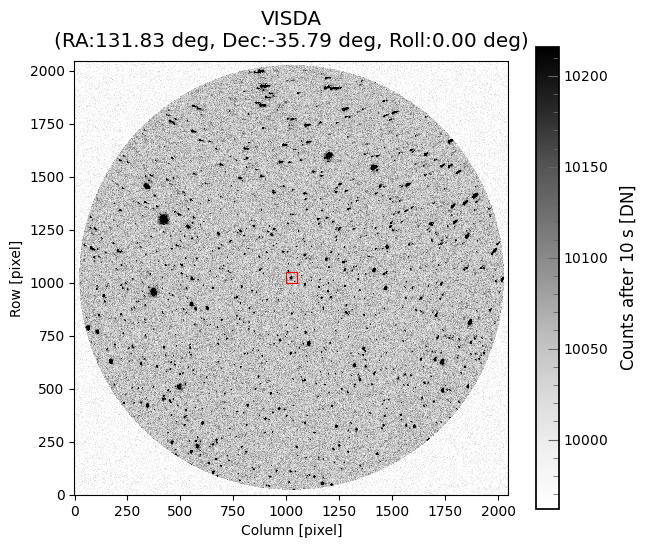

In [34]:
### Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays.
simVIS.show_FFI()

### retrieve a catalog of objects in the VIS FOV
cat = simVIS.source_catalog

### You can also print out other attributes
print(simVIS.ra, simVIS.dec, simVIS.wcs)

Creating an observation returns an astropy.io.fits.HDUList array. 
- `nreads` sets how many reads of the detector are coadded together to create a frame.
- `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
- `nframes` sets how many frames will be returned.
- `start_time` indicates the time of observation. 
- `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 

For some notebooks, you will want to use a "reduction factor" to speed up calculation by skipping some of the frames in the observation. A value of 1 means no reduction. For more intensive notebooks, you may want to use a value of 100.


In [35]:
### reduce the number of integrations to speed up calculations
reduction = 1 # set to 1 for no reduction

### Create an Observation.
data = simVIS.observe(nreads = frames_per_int_VIS, 
                      bin_frames = 1, 
                      nframes = int(num_int_VIS/reduction), 
                      start_time = start_time, 
                      output_type = "array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
print(data.shape)

Modeling Pixel Positions: 100%|██████████| 32/32 [00:39<00:00,  1.23s/it]


(1, 2400, 50, 50)


In [ ]:
### Plot animations of ROIs frame-to-frame. Adjust index to switch ROIs. 
# index = 0
# animate(data[index])

### If you want to save this:
#save_mp4(data[index], "3_60_animation.mp4")
#save_gif(data[index], "3_60_animation.gif")

### NIR Observation

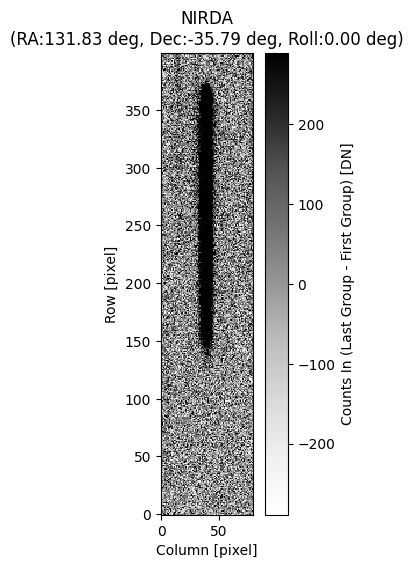

In [36]:
### Plot the NIRDA subarray 
simNIR.show_subarray();

Creating a NIR observation returns an astropy.io.fits.HDUList array. The following parameters can be adjusted:
- `SC_Resets1` : Number of reset frames at the start of the first integration of exposure
- `SC_Resets2` : Number of resent frames at the start of 1 through n integrations of exposure
- `SC_DropFrames1` : Number of dropped frames after reset of any integration of exposure
- `SC_DropFrames2` : Number of dropped frames in every group of integrations of exposure except the last group
- `SC_DropFrames3` : Number of dropped frames in the last group of each integration of exposure
- `SC_ReadFrames` : Number of frames read during each group of integration of exposure
- `SC_Groups` : Number of groups per integration of exposure
- `SC_Integrations` : Number of integrations per exposure
- `start_time` : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
- `noise` : bool flag determining whether noise is simulated and included. Default is True.
- `jitter` : bool flag determining whether jitter is simulated and included. Default is True.
- `output_type` : String flag to determine the result output. Valid strings are "fits" or "array


In [ ]:
# Create a NIRDA observation. 
data = simNIR.observe(SC_Integrations = int(num_int_NIR/reduction), 
                      SC_ReadFrames = stored_frames_per_int_NIR, 
                      start_time = start_time, 
                      output_type = "array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
print(data.shape)

In [ ]:
### Plot the NIRDA integration scheme 
### This is not set up for this observation right now
# plot_nirda_integrations(SC_Resets1=1,
#     SC_Resets2=1,
#     SC_DropFrames1=0,
#     SC_DropFrames2=16,
#     SC_DropFrames3=0,
#     SC_ReadFrames=obs_dict[nir]['frames_per_int'],
#     SC_Groups=2,
#     SC_Integrations=obs_dict[nir]['num_int']);

### Save the simulated observations

This .fits file cannot be uploaded to GitHub! They can instead be saved on Box.

FITS file extensions: 
1. PRIMARY with some information about the simulated observation 
2. SCIENCE with information about the data
3. ROIs with information about each ROI 

In [ ]:
### Convert observations to the correct format for the .fits file (i.e., output_type set to default) 
hdulist_vis = simVIS.observe(nreads=frames_per_int_VIS, 
                             bin_frames=1, 
                             nframes=int(num_int_VIS/reduction), start_time=start_time)

hdulist_nir = simNIR.observe(SC_Integrations=int(num_int_NIR/reduction),
                             SC_ReadFrames=stored_frames_per_int_NIR, start_time=start_time)


### Save our simulated observation in a fits file
targ = target.replace(" ", "")
VISrois_outfile =  ("3.21_VISrois_"
                     + str(targ)
                     + "_obs"
                     + str(observation_number)
                     + ".fits")
NIRrois_outfile =  ("3.21_NIRrois_"
                     + str(targ)
                     + "_obs"
                     + str(observation_number)
                     + ".fits" )

hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

Modeling Pixel Positions: 100%|██████████| 9/9 [00:06<00:00,  1.30it/s]


In [ ]:
### Print the third extension for  ROIs
# hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
# print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_ffis[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_ffis[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROI Headers --')
#print(hdul_ffis[2].header)

Filename: 3.10_ffis_pnt123_456705-005_666666.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  SCIENCE       1 ImageHDU        71   (1024, 1024, 200)   int64   
  2  ROITABLE      1 BinTableHDU     22   2R x 1C   [D]   
None


## Data Products

Right now, we aren't including much here. If useful, this section of the notebook could be used to perform and document analysis comparing the simulated observation to the true observation. 

## Generate SOC File

The format of the SOC file is currently being developed. Some variables may be removed/added/changed. We are working on defining these with SOC meetings.

**Some things to note:**
- All instances of RA and Dec in the XML generation cell should be just the decimal value and should not include the unit. Likely, appending `.value` to the end of the variable name will solve the issue.

**For VISDA related commands:**
- `ffi_flag`: 
    - 1 if the observations are FFIs, 
    - 0 otherwise (e.g. it's a SCIENCE observation).
- `VIS_StarRoiDetMethod`: 
    - 1 if the notebook is explicitly specifying the RA and DEC values of additional regions for the visible camera to save (this is task-dependent), 
    - 2 otherwise
- `VIS_IncludeFieldSolnsInResp`: should always be 1.
- `VIS_StarRoiDimension`: expects a list [VIS_xpix, VIS_ypix]
- `VIS_MaxNumStarRois`: 
    - 0 if `VIS_StarRoiDetMethod` - 0, 
    - otherwise if `VIS_StarRoiDetMethod` is 1, `VIS_MaxNumStarRois` should be the number of ROIs specified by the notebook (9 if the notebook doesn`t explicitly specify).
- `VIS_numPredefinedStarRois`: 
    - Should be equal to the number of explicit additional regions that are being specified by the notebook.
    - This number is only >0 if `VIS_StarRoiDetMethod` is 0, otherwise `VIS_numPredefinedStarRois` = 0.
- The `VIS_PredefinedStarRoi` RA and Dec commands should be lists of RAs and Decs in decimal format without the unit (again, the `.value` might need to be added after the RRA and Dec variables to accomplish this).
- `VIS_NumExposuresMax` should be equal to or greater than the value of `VIS_NumTotalFramesRequested`.


**For NIRDA related commands:**
- If the NIRDA is not used by the task, all related commands should be set to empty strings
- `NIR_AvgGroups` should be set to either 0 or 1 
    - 0 if the task requires every single frame to be recorded for the NIR observations and 
    - 1 if this is not the case.
- Some NIR commands should be the same value no matter what:
    -  `NIR_SC_Resets1`: 1
    - `NIR_SC_Resets2`: 1
    - `NIR_SC_DropFrames1`: 0
    - `NIR_SC_DropFrames3`: 0
- `NIR_SC_DropFrames2` should be 0 if every single NIR frame is being requested by the task, otherwise it should be 16
- The value of `NIR_SC_ReadFrames` could be a couple of values:
    - If every frame is being requested by the task (e.g. `NIR_AvgGroups` = 0 and `NIR_SC_DropFrames2` = 0), `NIR_SC_ReadFrames` is equal to the `stored_frames_per_int` variable defined at the top, or equivalent variable (potentially an entry from an obs_dict).
    - Otherwise, in normal operations, it should be equal to the value of `stored_frames_per_int` (or equvalent obs_dict variable) divided by the number of groups, which I think for all of our relevant cases is 2, so `NIR_SC_Read_Frames` = `stored_frames_per_int` / 2
- `NIR_SC_Groups` should always be 2 (for commissioning  purposes, as far as is currently known), unless every frame is being requested by  the task, in which case it should be equal to 1.




In [24]:
### Here we define the information required for scheduling the observation. ### 

variables = {
    'visit_id': '3.21', ### setting based on task number, for now. Could change.
    'obs_id': f"{observation_number:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time.strftime('%Y-%m-%dT%H:%M:%SZ'), 
    'stop_time': end_time.strftime('%Y-%m-%dT%H:%M:%SZ'), 
    'RA': c.ra.deg,
    'DEC': c.dec.deg,

    ### Leave as empty strings if notebook requires no NIR.
    'NIR_AvgGroups': 0,  ### 1 if Fowler sampling, 0 if keeping every frame 
    'NIR_ROI_StartX': NIR_ROI_StartX, 
    'NIR_ROI_StartY': NIR_ROI_StartY, 
    'NIR_ROI_SizeX': NIR_ROI_SizeX, 
    'NIR_ROI_SizeY': NIR_ROI_SizeY,
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 0,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': stored_frames_per_int_NIR,
    'NIR_targetID': target_names[observation_number], 
    'NIR_SC_Groups': 1,
    'NIR_SC_Integrations': num_int_NIR,

    'ffi_flag': 0, # 0 for no FFIs, 1 if task includes full frame images
    'VIS_StarRoiDetMethod': 1,  ### 1: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 2: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': frames_per_int_VIS,
    'VIS_NumTotalFramesRequested': num_int_VIS*frames_per_int_VIS,
    'VIS_TargetRA': c.ra.deg,
    'VIS_TargetDEC': c.dec.deg,
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
    'VIS_MaxNumStarRois': 0, ### max number of star ROis that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': 1, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': '', 
    'VIS_PredefinedStarRoiDec': '', 
    'VIS_targetID': target_names[observation_number], 
    'VIS_NumExposuresMax': num_int_VIS*frames_per_int_VIS, 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [25]:
### Generate the SOC .xml file ### 

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_SOC.xml' 
generate_task_plan(variables, output_soc_file)